In [26]:
# Import statements
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from statsmodels.tsa.stattools import acf
from matplotlib import colormaps
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from scipy.optimize import linear_sum_assignment
import ruptures as rpt
from sklearn.decomposition import PCA, KernelPCA

In [27]:
cases_plot = pd.read_csv('cases_total.csv')
cases_plot['date'] = pd.to_datetime(cases_plot['date'])
cases_plot.set_index('date',inplace=True)
counts = cases_plot[cases_plot['area_name']=='Maidstone']

In [28]:
wide_data_incidence = pd.read_csv('wide_incidence_full.csv',header=[0,1], index_col=0)
wide_data_total = pd.read_csv('wide_total_full.csv',header=[0,1], index_col=0)
npis = pd.read_csv('ltla_to_nhs.csv')
weekly_counts_total = pd.read_csv('weekly_total_full.csv')
test = wide_data_incidence.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_incidence = test
test = wide_data_total.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_total = test

In [29]:
import pickle        
with open('ltla_transitions.pkl', 'rb') as f:
    ltla_transitions = pickle.load(f)

In [30]:
def is_constant(series):
    return np.all(series == series[0])

def is_low_variance(series, threshold=1e-5):
    return np.var(series) < threshold

def normalised_2sigma_ang(ts):
    ts = pd.Series(ts)
    rolling_mean = ts.rolling(window=50).mean()
    rolling_std = ts.rolling(window=50).std(ddof=0)
    normalise_stats = (ts - rolling_mean)/rolling_std

    n = len(normalise_stats)
    mean_val = np.zeros(n)
    std_val= np.zeros(n)
    for j in range(n):
        mean_val[j] = np.nanmean(normalise_stats[1:j+1])
        std_val[j] = np.nanstd(normalise_stats[1:j+1])

    indices_greater = [ n for n,i in enumerate(range(len(normalise_stats))) if (normalise_stats[i])>(mean_val+2*std_val)[i] ]
    indices_smaller =  [ n for n,i in enumerate(range(len(normalise_stats))) if (normalise_stats[i])<(mean_val-2*std_val)[i] ]
    all_indices = np.setdiff1d(np.unique(indices_greater + indices_smaller ),[1])    

    return all_indices

def twosigma_ang(ts):
    normalise_stats = pd.Series(ts)

    n = len(normalise_stats)
    mean_val = np.zeros(n)
    std_val= np.zeros(n)
    for j in range(n):
        mean_val[j] = np.nanmean(normalise_stats[1:j+1])
        std_val[j] = np.nanstd(normalise_stats[1:j+1])

    indices_greater = [ n for n,i in enumerate(range(len(normalise_stats))) if (normalise_stats[i])>(mean_val+2*std_val)[i] ]
    indices_smaller =  [ n for n,i in enumerate(range(len(normalise_stats))) if (normalise_stats[i])<(mean_val-2*std_val)[i] ]
    all_indices = np.setdiff1d(np.unique(indices_greater + indices_smaller ),[1])    

    return all_indices

def cossine_sim(ts):
    cos_sims = [0]

    for i in range(1, len(ts)):
        if np.linalg.norm(ts[i-1]) == 0:
            cos_sims.append(np.nan)
        else:
            dot_product = np.abs(np.dot(ts[i-1], ts[i]))
            norm_product = np.linalg.norm(ts[i-1]) * np.linalg.norm(ts[i])
            cos_sim = dot_product / norm_product
            cos_sims.append(cos_sim)

    return np.array(cos_sims)

def angle_displacement(ts):
    angle_displacements = [0]

    for i in range(1, len(ts)):
        if np.linalg.norm(ts[i-1]) == 0:
            angle_displacements.append(np.nan)
        else:
            dot_product = np.dot(ts[i-1], ts[i])
            norm_product = np.linalg.norm(ts[i-1]) * np.linalg.norm(ts[i])
            cos_sim = dot_product / norm_product
            # angle = np.arccos(np.clip(cos_sim, -1.0, 1.0))
            angle = np.arccos(np.abs(cos_sim))
            angle_displacements.append(angle)

    return np.array(angle_displacements)

def cusum(data, threshold=0.1, drift=0, noise_std=0.01):
    pos_cusum = np.zeros(len(data))
    signal_indices = np.zeros(len(data))
    for i in range(1, len(data)):
        pos_cusum[i] = max(0, pos_cusum[i-1] + data[i] - drift - noise_std)
        if pos_cusum[i] > threshold:
            pos_cusum[i] = 0  # Reset after signal
            signal_indices[i] = 1
    return signal_indices

def eigen_decomp(cov):
    size = cov.shape[1]
    cov_total = np.zeros(len(cov.index.get_level_values(0).unique()))
    cov_var = np.zeros(len(cov.index.get_level_values(0).unique()))
    cov_evec = np.zeros((len(cov.index.get_level_values(0).unique()),size))
    cov_evec2 = np.zeros((len(cov.index.get_level_values(0).unique()),size))
    Arot_norm = [0]
    V_store = []
    V_prev = []
    win_flag = True
    for i, date in enumerate(cov.index.get_level_values(0).unique()):
        if not(np.isnan(cov.loc[date].to_numpy()[0,0])):
            eigenvalues, eigenvectors = np.linalg.eigh(cov.loc[date].to_numpy())
            cov_total[i] = eigenvalues[-1]
            cov_var[i] = eigenvalues[-1]/np.linalg.norm(eigenvalues)
            cov_evec[i, :] = eigenvectors[:, -1].flatten()
            cov_evec2[i, :] = eigenvectors[:, -2].flatten()
            # Rotation rate
            V = np.copy(eigenvectors)
            if win_flag:
                V_prev = V.copy()
                V_store.append(V.copy())
                perm_store = [np.arange(V.shape[1])]
                win_flag = False
            else:
                V_aligned, perm = match_and_phase_align(V_prev, V)
                V_store.append(V_aligned.copy())
                perm_store.append(perm)
                # estimate derivative:
                dt = 1
                dV = (V_aligned - V_prev) / dt
                A_est = np.linalg.inv(V_prev) @ dV
                Arot_norm.append(np.linalg.norm(A_est, ord='fro'))
                V_prev = V_aligned.copy()
        else:
            cov_evec[i] = np.array(size*[0])
            cov_evec2[i] = np.array(size*[0])
            cov_total[i] = np.nan
            cov_var[i] = np.nan
            V_store.append(np.zeros((size,size)))
            Arot_norm.append(0)
            
    return cov_total, cov_var, cov_evec, cov_evec2, np.array(V_store),np.array(Arot_norm)

def vec_align(cov_evec):
    dots = np.sum(cov_evec[1:] * cov_evec[:-1], axis=1)
    signs = np.where(dots < 0, -1.0, 1.0)
    signs = np.insert(signs, 0, 1.0)
    cov_evec_aligned = cov_evec * np.cumprod(signs)[:, None]
    return cov_evec_aligned

# helper functions for fixing eigenbasis instabilities
def match_and_phase_align(V_prev, V_curr):
    # match columns
    M = np.abs(V_prev.conj().T @ V_curr)
    row_ind, col_ind = linear_sum_assignment(-M)
    Vc = V_curr[:, col_ind]

    # phase-align each column to previous
    for i in range(V_prev.shape[1]):
        s = np.vdot(V_prev[:, i], Vc[:, i])   # v_prev^H v_curr
        if np.abs(s) > 0:
            phase = s / np.abs(s)
            Vc[:, i] = Vc[:, i] * np.conj(phase)
        else:
            # fallback: if dot is zero, try sign or leave as is
            pass
    return Vc, col_ind

def find_bkps(evec, min_size=10, pen=20):
    # change point detection
    model = "l1"
    algo = rpt.Pelt(model=model, min_size=min_size).fit(evec)
    bkps = algo.predict(pen=pen)
    return np.array(bkps)

from itertools import tee, cycle
# Adapted from ruptures plotting code
def pairwise(iterable):
    """S -> (s0,s1), (s1,s2), (s2, s3), ..."""
    a, b = tee(iterable)
    next(b, None)
    return zip(a, b)
color_cycle = cycle(["#4286f4", "#f44174"])

def get_signals_and_bkps(evectors_100, evectors_60, threshold = (0.1,0.2), std = (0.01,0.03), min_size = (10,10), pen = (20,20)):
    ang_100_raw = angle_displacement(evectors_100)
    ang_100_flags = cusum(ang_100_raw, threshold=threshold[0], noise_std=std[0]).astype(bool)
    ang_sig_100_flags = twosigma_ang(ang_100_raw)
    ang_normsig_100_flags = normalised_2sigma_ang(ang_100_raw)

    ang_60_raw = angle_displacement(evectors_60)
    ang_60_flags = cusum(ang_60_raw, threshold=threshold[1], noise_std=std[1]).astype(bool)
    ang_60_flags = twosigma_ang(ang_60_raw)
    ang_normsig_60_flags = normalised_2sigma_ang(ang_60_raw)

    bkps_100 = find_bkps(evectors_100, min_size=min_size[0], pen=pen[0])
    bkps_60 = find_bkps(evectors_60, min_size=min_size[1], pen=pen[1])

    return ang_100_flags, ang_sig_100_flags, ang_normsig_100_flags, bkps_100, ang_60_flags, ang_60_flags, ang_normsig_60_flags, bkps_60

## Maidstone 10-year

In [31]:
wide_data_incidence = pd.read_csv('wide_incidence_10year_full.csv',header=[0,1], index_col=0)
wide_data_total = pd.read_csv('wide_total_10year_full.csv',header=[0,1], index_col=0)
npis = pd.read_csv('ltla_to_nhs.csv')
weekly_counts_total = pd.read_csv('weekly_total_10year_full.csv')
test = wide_data_incidence.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_incidence = test
test = wide_data_total.reset_index()
test.date = pd.to_datetime(test.date)
test = test[test.date >= pd.to_datetime('2020-06-01')]
wide_data_total = test

In [32]:
rolling = wide_data_incidence['Maidstone'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total, cov_100_var, cov_100_evec, cov_100_evec2, V_store_100, Arot_norm_100 = eigen_decomp(cov)

rolling = wide_data_incidence['Maidstone'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total, cov_60_var, cov_60_evec, cov_60_evec2, V_store_60, Arot_norm_60 = eigen_decomp(cov)

rolling = wide_data_total['Maidstone'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total_det, cov_100_var_det, cov_100_evec_det, cov_100_evec_det2, V_store_100_det, Arot_norm_100_det = eigen_decomp(cov)

rolling = wide_data_total['Maidstone'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total_det, cov_60_var_det, cov_60_evec_det, cov_60_evec_det2, V_store_60_det, Arot_norm_60_det = eigen_decomp(cov)

ang_100_flags, ang_sig_100_flags, ang_normsig_100_flags, bkps_100, ang_60_flags, ang_sig_60_flags, ang_normsig_60_flags, bkps_60 = get_signals_and_bkps(cov_100_evec, cov_60_evec)
ang_100_flags_det, ang_sig_100_flags_det, ang_normsig_100_flags_det, bkps_100_det, ang_60_flags_det, ang_sig_60_flags_det, ang_normsig_60_flags_det, bkps_60_det = get_signals_and_bkps(cov_100_evec_det, cov_60_evec_det)

/tmp/ipykernel_17290/993437236.py:33: RuntimeWarning: Mean of empty slice
  mean_val[j] = np.nanmean(normalise_stats[1:j+1])
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_17290/993437236.py:17: RuntimeWarning: Mean of empty slice
  mean_val[j] = np.nanmean(normalise_stats[1:j+1])


/tmp/ipykernel_17290/3895016916.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['value'].rolling(7).mean()


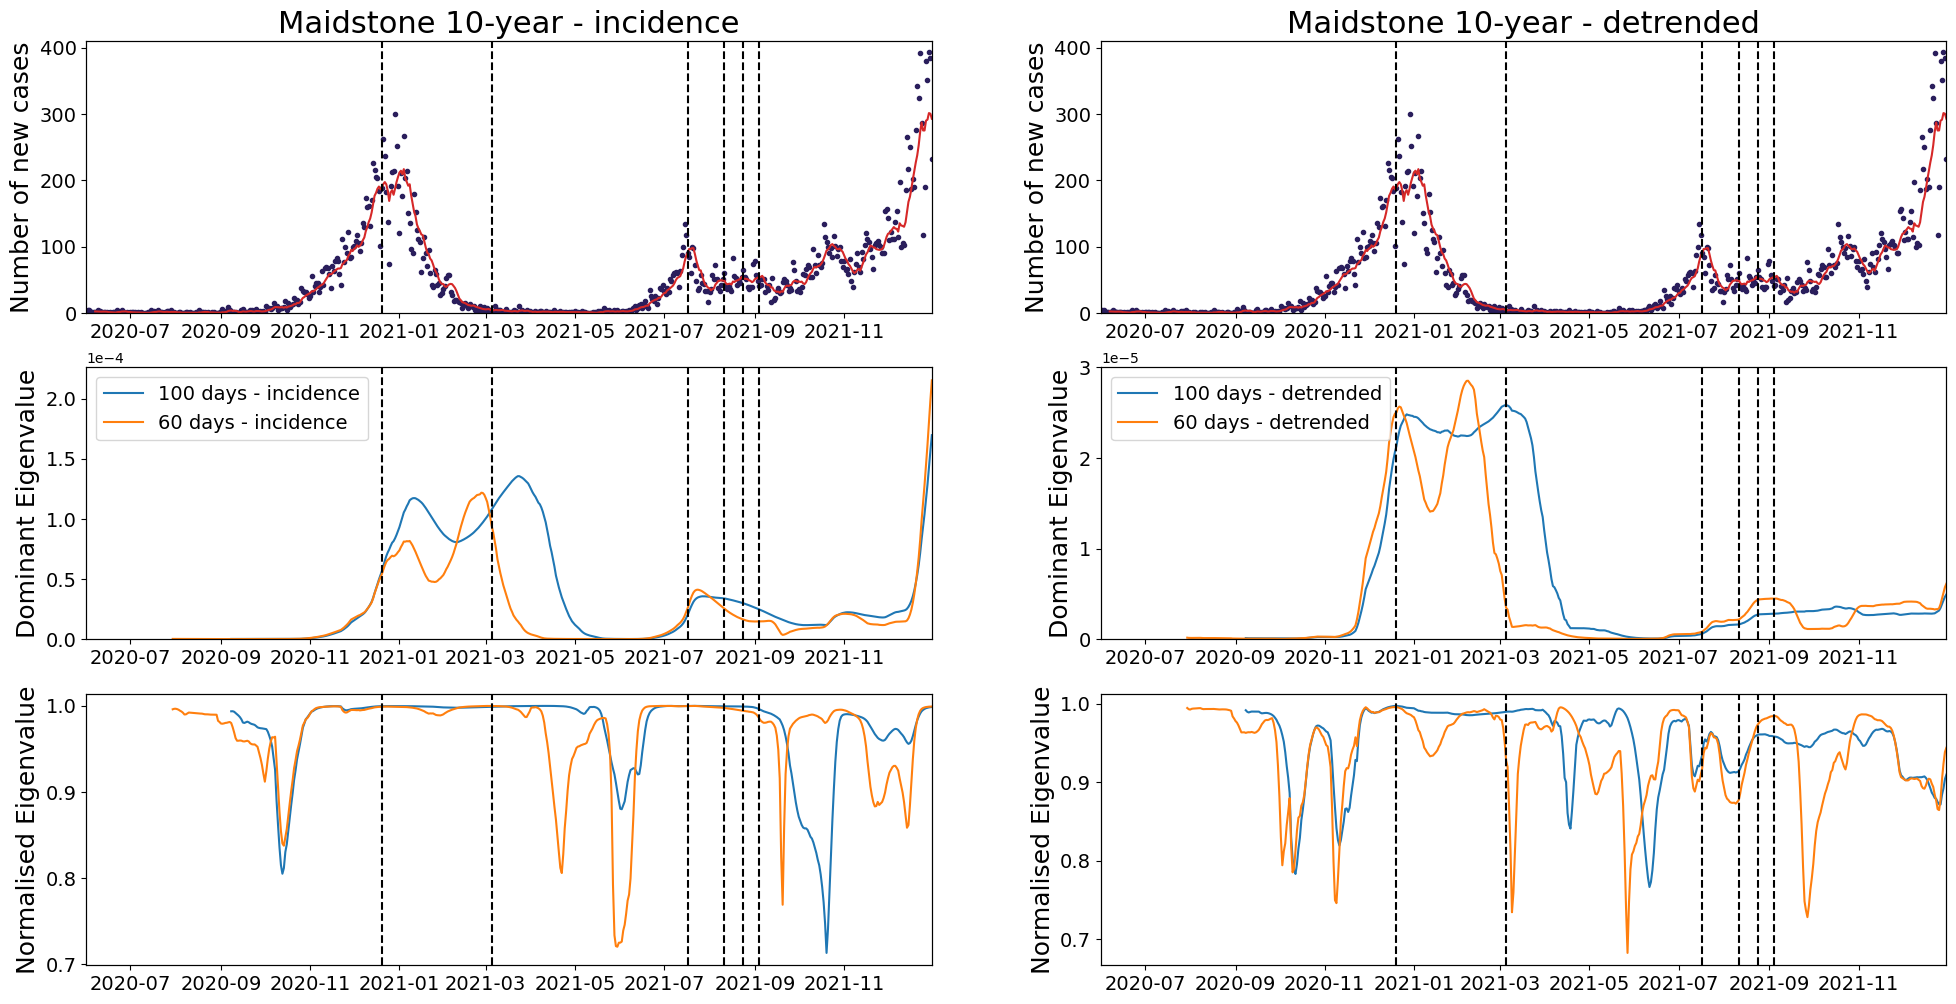

In [33]:
counts = cases_plot[cases_plot['area_name']=='Maidstone']
fig, axs = plt.subplots(nrows=3,ncols=2,figsize=(24,12))
counts['rolling'] = counts['value'].rolling(7).mean()
counts = counts.reset_index()
axs[0,0].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,0].set_ylim((0,410))
axs[0,0].set_title('Maidstone 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[1,0].plot(counts['date'],cov_100_total,label='100 days - incidence')
axs[2,0].plot(counts['date'],cov_100_var,label='100 days - incidence')
axs[1,0].plot(counts['date'],cov_60_total,label='60 days - incidence')
axs[2,0].plot(counts['date'],cov_60_var,label='60 days - incidence')
axs[1,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
axs[1,0].set_ylim((0,None))
axs[1,1].set_ylim((0,3e-5))
axs[1,0].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,0].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,0].legend(fontsize=14,loc='upper left')

axs[0,1].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,1].set_ylim((0,410))
axs[0,1].set_title('Maidstone 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[1,1].plot(counts['date'],cov_100_total_det,label='100 days - detrended')
axs[2,1].plot(counts['date'],cov_100_var_det,label='100 days - detrended')
axs[1,1].plot(counts['date'],cov_60_total_det,label='60 days - detrended')
axs[2,1].plot(counts['date'],cov_60_var_det,label='60 days - detrended')
axs[1,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,1].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,1].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,1].legend(fontsize=14,loc='upper left')
for i in range(3):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=ltla_transitions['Maidstone'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
        axs[i,j].tick_params(axis='both',labelsize=14)
plt.savefig("Figures/10yearevalues.pdf",dpi=2400,bbox_inches='tight')
plt.show()

/tmp/ipykernel_17290/1975256374.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['value'].rolling(7).mean()


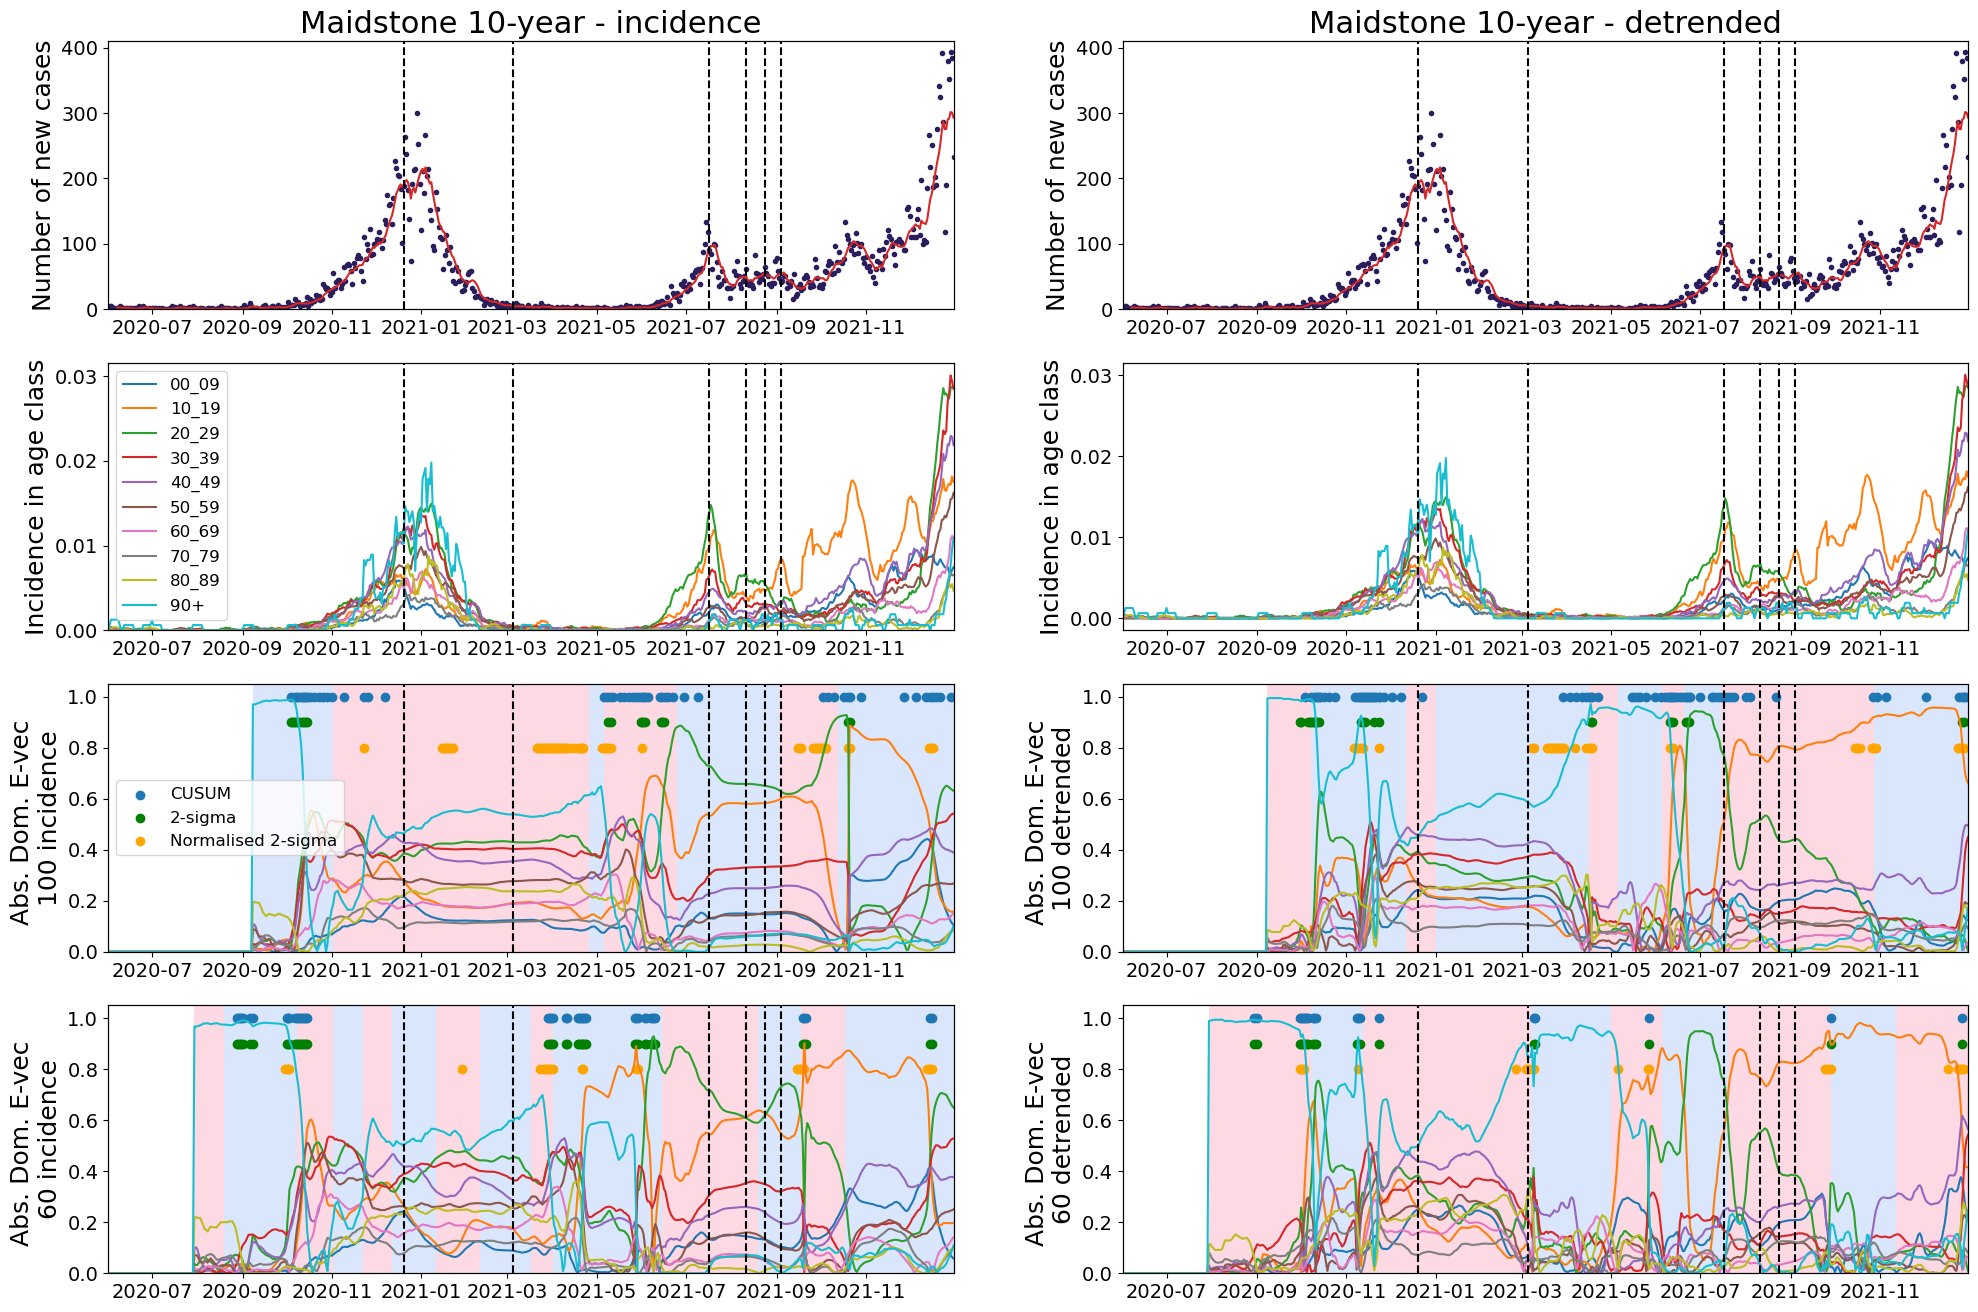

In [ ]:
labs = ['00_09', '10_19', '20_29', '30_39', '40_49', '50_59', '60_69', '70_79','80_89', '90+']
counts = cases_plot[cases_plot['area_name']=='Maidstone']
cols = colormaps.get_cmap('tab10')(np.arange(10))
fig, axs = plt.subplots(nrows=4,ncols=2,figsize=(24,16))
counts['rolling'] = counts['value'].rolling(7).mean()
counts = counts.reset_index()

axs[0,0].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,0].set_ylim((0,410))
axs[0,0].set_title('Maidstone 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)

for i in range(len(labs)):
    t = wide_data_incidence.Maidstone[labs[i]]
    axs[1,0].plot(counts['date'],t,label=labs[i])
axs[1,0].set_ylabel('Incidence in age class',fontsize=18)
axs[1,0].legend(fontsize=12,loc='upper left')
axs[1,0].set_ylim((0,None))

for i in range(len(cov_100_evec[0])):
    axs[2,0].plot(counts['date'],np.abs(cov_100_evec[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([100],bkps_100))-1]), color_cycle):
    axs[2,0].axvspan(start, end, facecolor=col, alpha=0.2)
axs[2,0].scatter(counts['date'][ang_100_flags],np.ones(len(np.arange(len(cov_100_evec))[ang_100_flags])), label = 'CUSUM')
axs[2,0].scatter(counts['date'][ang_sig_100_flags], np.ones(len(ang_sig_100_flags))*0.9, color='g', label = '2-sigma')
axs[2,0].scatter(counts['date'][ang_normsig_100_flags], np.ones(len(ang_normsig_100_flags))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[2,0].set_ylabel('Abs. Dom. E-vec \n100 incidence',fontsize=18)
axs[2,0].legend(loc='center left',fontsize=12)
axs[2,0].set_ylim((0,None))

for i in range(len(cov_60_evec[0])):
    axs[3,0].plot(counts['date'],np.abs(cov_60_evec[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([60],bkps_60))-1]), color_cycle):
    axs[3,0].axvspan(start, end, facecolor=col, alpha=0.2)
axs[3,0].scatter(counts['date'][ang_60_flags],np.ones(len(np.arange(len(cov_60_evec))[ang_60_flags])), label = 'CUSUM')
axs[3,0].scatter(counts['date'][ang_sig_60_flags], np.ones(len(ang_sig_60_flags))*0.9, color='g', label = '2-sigma')
axs[3,0].scatter(counts['date'][ang_normsig_60_flags], np.ones(len(ang_normsig_60_flags))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[3,0].set_ylabel('Abs. Dom. E-vec \n60 incidence',fontsize=18)
axs[3,0].set_ylim((0,None))

axs[0,1].plot(counts['date'],counts['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,1].set_ylim((0,410))
axs[0,1].set_title('Maidstone 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)

for i in range(len(labs)):
    t = wide_data_incidence.Maidstone[labs[i]]
    axs[1,1].plot(counts['date'],t,label=labs[i])
axs[1,1].set_ylabel('Incidence in age class',fontsize=18)

for i in range(len(cov_100_evec_det[0])):
    axs[2,1].plot(counts['date'],np.abs(cov_100_evec_det[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([100],bkps_100_det))-1]), color_cycle):
    axs[2,1].axvspan(start, end, facecolor=col, alpha=0.2)
axs[2,1].scatter(counts['date'][ang_100_flags_det],np.ones(len(np.arange(len(cov_100_evec_det))[ang_100_flags_det])), label = 'CUSUM')
axs[2,1].scatter(counts['date'][ang_sig_100_flags_det], np.ones(len(ang_sig_100_flags_det))*0.9, color='g', label = '2-sigma')
axs[2,1].scatter(counts['date'][ang_normsig_100_flags_det], np.ones(len(ang_normsig_100_flags_det))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[2,1].set_ylabel('Abs. Dom. E-vec \n100 detrended',fontsize=18)
axs[2,1].set_ylim((0,None))

for i in range(len(cov_60_evec_det[0])):
    axs[3,1].plot(counts['date'],np.abs(cov_60_evec_det[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([60],bkps_60_det))-1]), color_cycle):
    axs[3,1].axvspan(start, end, facecolor=col, alpha=0.2)
axs[3,1].scatter(counts['date'][ang_60_flags_det],np.ones(len(np.arange(len(cov_60_evec_det))[ang_60_flags_det])), label = 'CUSUM')
axs[3,1].scatter(counts['date'][ang_sig_60_flags_det], np.ones(len(ang_sig_60_flags_det))*0.9, color='g', label = '2-sigma')
axs[3,1].scatter(counts['date'][ang_normsig_60_flags_det], np.ones(len(ang_normsig_60_flags_det))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[3,1].set_ylabel('Abs. Dom. E-vec \n60 detrended',fontsize=18)
axs[3,1].set_ylim((0,None))

for i in range(4):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=ltla_transitions['Maidstone'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
        axs[i,j].tick_params(axis='both',labelsize=14)
plt.savefig("Figures/10yearevectors.pdf",dpi=2400,bbox_inches='tight')
plt.show()

## NHS regional

In [36]:
wide_data_incidence_nhs = pd.read_csv('wide_incidence_region.csv',index_col=0)
wide_data_total_nhs = pd.read_csv('wide_total_region.csv',index_col=0)
weekly_counts_total_nhs = pd.read_csv('weekly_total_region.csv')

from copy import deepcopy
national_transitions = np.load('england_transitions.npy',allow_pickle=True)

In [37]:
cases_nhs_full = pd.read_csv('cases_total.csv')
cases_nhs_full['date'] = pd.to_datetime(cases_nhs_full['date'])
cases_nhs_full.set_index('date',inplace=True)
npis = pd.read_csv('ltla_to_nhs.csv')
manual_dat = pd.DataFrame({'ltla20nm': ['Wycombe','South Bucks','Chiltern','Aylesbury Vale','Cornwall and Isles of Scilly', 'Hackney and City of London'], \
                           'region': ['South East', 'South East', 'South East', 'South East', 'South West', 'London']})
npis = pd.concat([npis,manual_dat])
pop_nhs = pd.read_csv('census_estimate.csv')
ltla_pop = pd.read_csv('newCasesPCROnlyBySpecimenDate_ltla_2020.csv')
ltla_pop = ltla_pop[['area_code','area_name']]
ltla_pop.drop_duplicates(inplace=True)
ltla_pop = pd.merge(ltla_pop, npis, left_on='area_name', right_on='ltla20nm').drop(columns='ltla20nm')
ltla_pop = pd.merge(ltla_pop, pop_nhs)
nhs_pop = ltla_pop.groupby('region').sum().drop(columns=['area_code','area_name','Unnamed: 0'])
nhs_pop.reset_index(inplace=True)

cases_nhs = pd.merge(cases_nhs_full.reset_index(), npis, left_on='area_name', right_on='ltla20nm')
cases_nhs.drop(columns=['ltla20nm','area_name','area_code','Unnamed: 0'],inplace=True)
cases_nhs = cases_nhs.groupby(['date','region']).sum().reset_index().set_index('date')

cases_total = cases_nhs.reset_index().drop(columns='region').groupby('date').sum()
cases_total['rolling'] = cases_total.rolling(7).mean()

cases_nhs['rolling'] = np.NaN
cases_nhs = cases_nhs.reset_index()
for r in np.unique(cases_nhs.region.values):
    t = cases_nhs.reset_index()
    t = t[t.region == r].set_index('date')['value'].rolling(7).mean()
    cases_nhs.loc[cases_nhs['region'] == r,'rolling'] = t.values

In [38]:
rolling = wide_data_incidence_nhs.rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total, cov_100_var, cov_100_evec, cov_100_evec2, V_store_100, Arot_norm_100 = eigen_decomp(cov)

rolling = wide_data_incidence_nhs.rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total, cov_60_var, cov_60_evec, cov_60_evec2, V_store_60, Arot_norm_60 = eigen_decomp(cov)

rolling = wide_data_total_nhs.rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total_det, cov_100_var_det, cov_100_evec_det, cov_100_evec_det2, V_store_100_det, Arot_norm_100_det = eigen_decomp(cov)

rolling = wide_data_total_nhs.rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total_det, cov_60_var_det, cov_60_evec_det, cov_60_evec_det2, V_store_60_det, Arot_norm_60_det = eigen_decomp(cov)

ang_100_flags, ang_sig_100_flags, ang_normsig_100_flags, bkps_100, ang_60_flags, ang_sig_60_flags, ang_normsig_60_flags, bkps_60 = get_signals_and_bkps(cov_100_evec, cov_60_evec,threshold = (0.2,0.4), std = (0.005,0.01), min_size = (20,20), pen = (20,20))
ang_100_flags_det, ang_sig_100_flags_det, ang_normsig_100_flags_det, bkps_100_det, ang_60_flags_det, ang_sig_60_flags_det, ang_normsig_60_flags_det, bkps_60_det = get_signals_and_bkps(cov_100_evec_det, cov_60_evec_det,threshold = (0.2,0.4), std = (0.005,0.01), min_size = (20,20), pen = (30,30))

/tmp/ipykernel_17290/993437236.py:33: RuntimeWarning: Mean of empty slice
  mean_val[j] = np.nanmean(normalise_stats[1:j+1])
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_17290/993437236.py:17: RuntimeWarning: Mean of empty slice
  mean_val[j] = np.nanmean(normalise_stats[1:j+1])


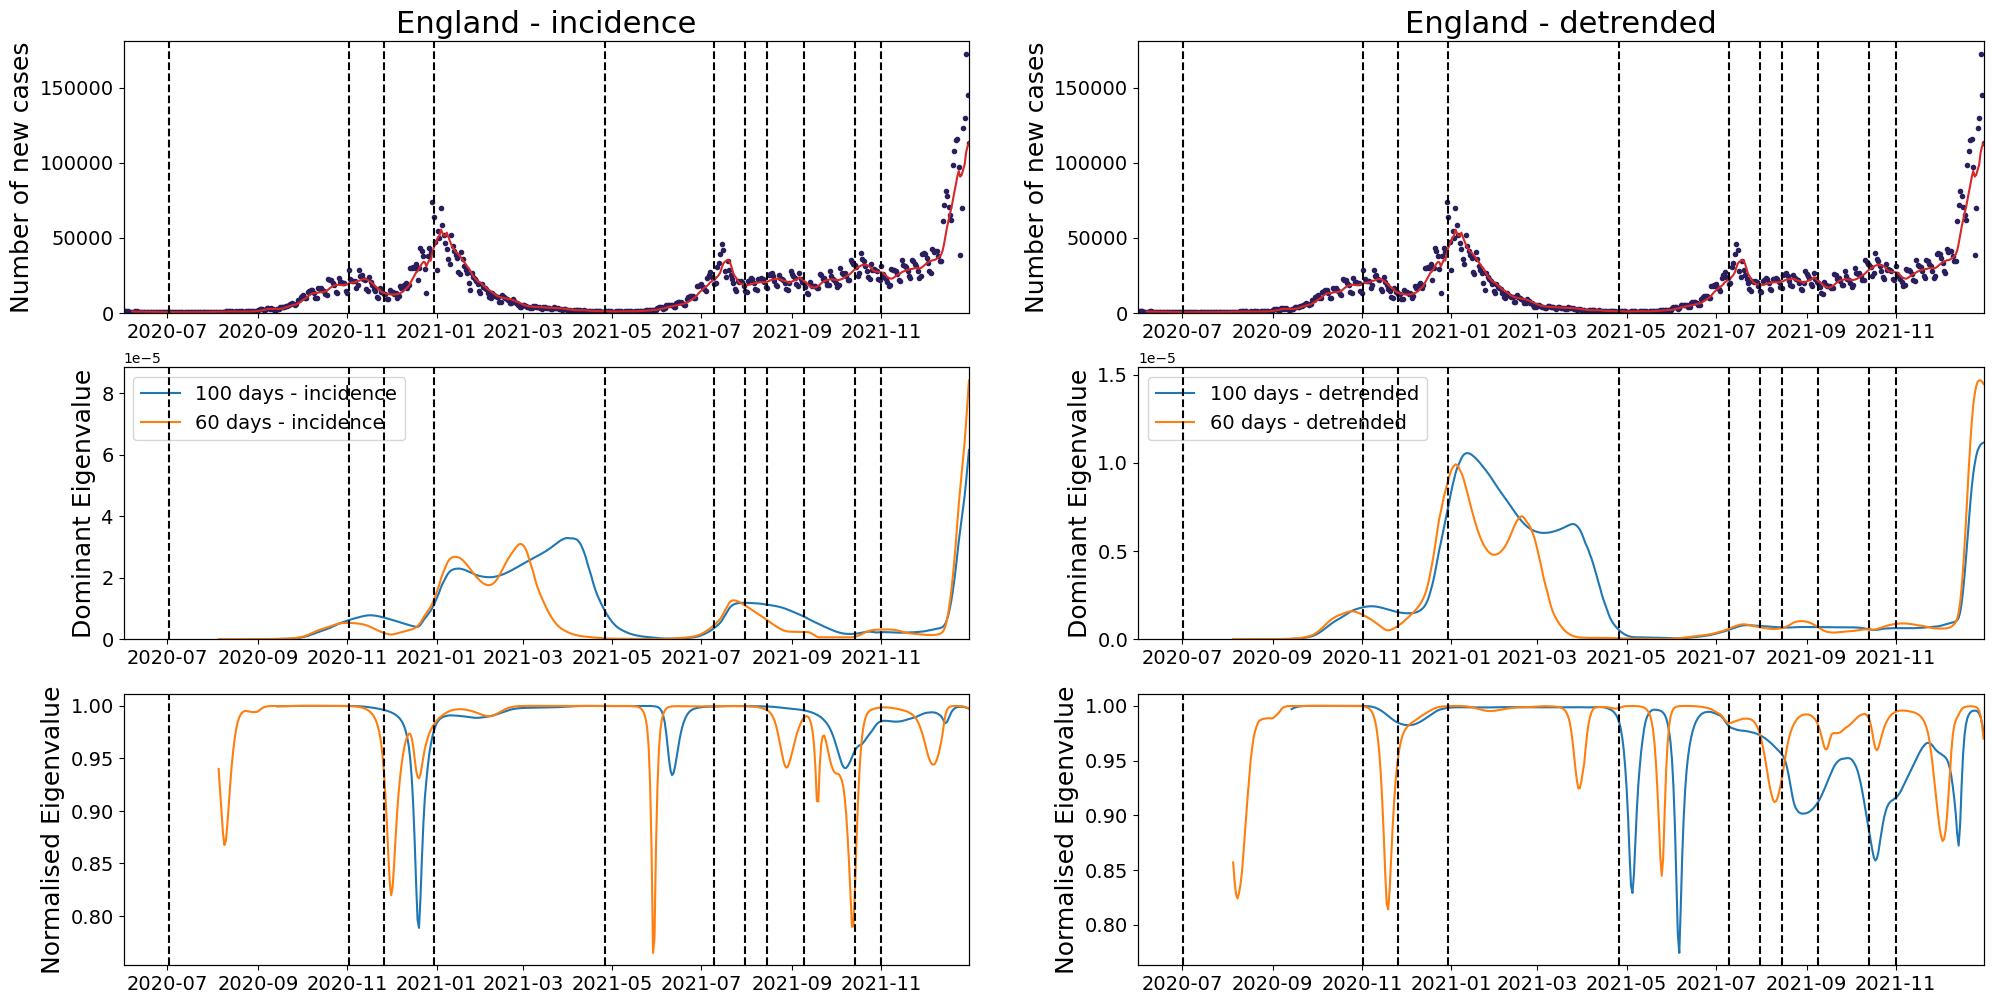

In [40]:
fig, axs = plt.subplots(nrows=3,ncols=2,figsize=(24,12))
counts_nhs = deepcopy(cases_total)
counts_nhs = counts_nhs.reset_index()

axs[0,0].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,0].set_title('England - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[0,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,0].plot(counts_nhs['date'],cov_100_total,label='100 days - incidence')
axs[2,0].plot(counts_nhs['date'],cov_100_var,label='100 days - incidence')
axs[1,0].plot(counts_nhs['date'],cov_60_total,label='60 days - incidence')
axs[2,0].plot(counts_nhs['date'],cov_60_var,label='60 days - incidence')
axs[1,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[2,0].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,0].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,0].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,0].legend(fontsize=14,loc='upper left')
axs[1,0].set_ylim((0,None))
axs[0,0].set_ylim((0,None))

axs[0,1].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,1].set_title('England - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[0,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,1].plot(counts_nhs['date'],cov_100_total_det,label='100 days - detrended')
axs[2,1].plot(counts_nhs['date'],cov_100_var_det,label='100 days - detrended')
axs[1,1].plot(counts_nhs['date'],cov_60_total_det,label='60 days - detrended')
axs[2,1].plot(counts_nhs['date'],cov_60_var_det,label='60 days - detrended')
axs[1,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[2,1].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
axs[1,1].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,1].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,1].legend(fontsize=14,loc='upper left')
axs[1,1].set_ylim((0,None))
axs[0,1].set_ylim((0,None))

for i in range(3):
    for j in range(2):
        axs[i,j].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=national_transitions[:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
        axs[i,j].tick_params(axis='both',labelsize=14)
plt.savefig('Figures/NHSevalues.pdf',dpi=2400,bbox_inches='tight')
plt.show()

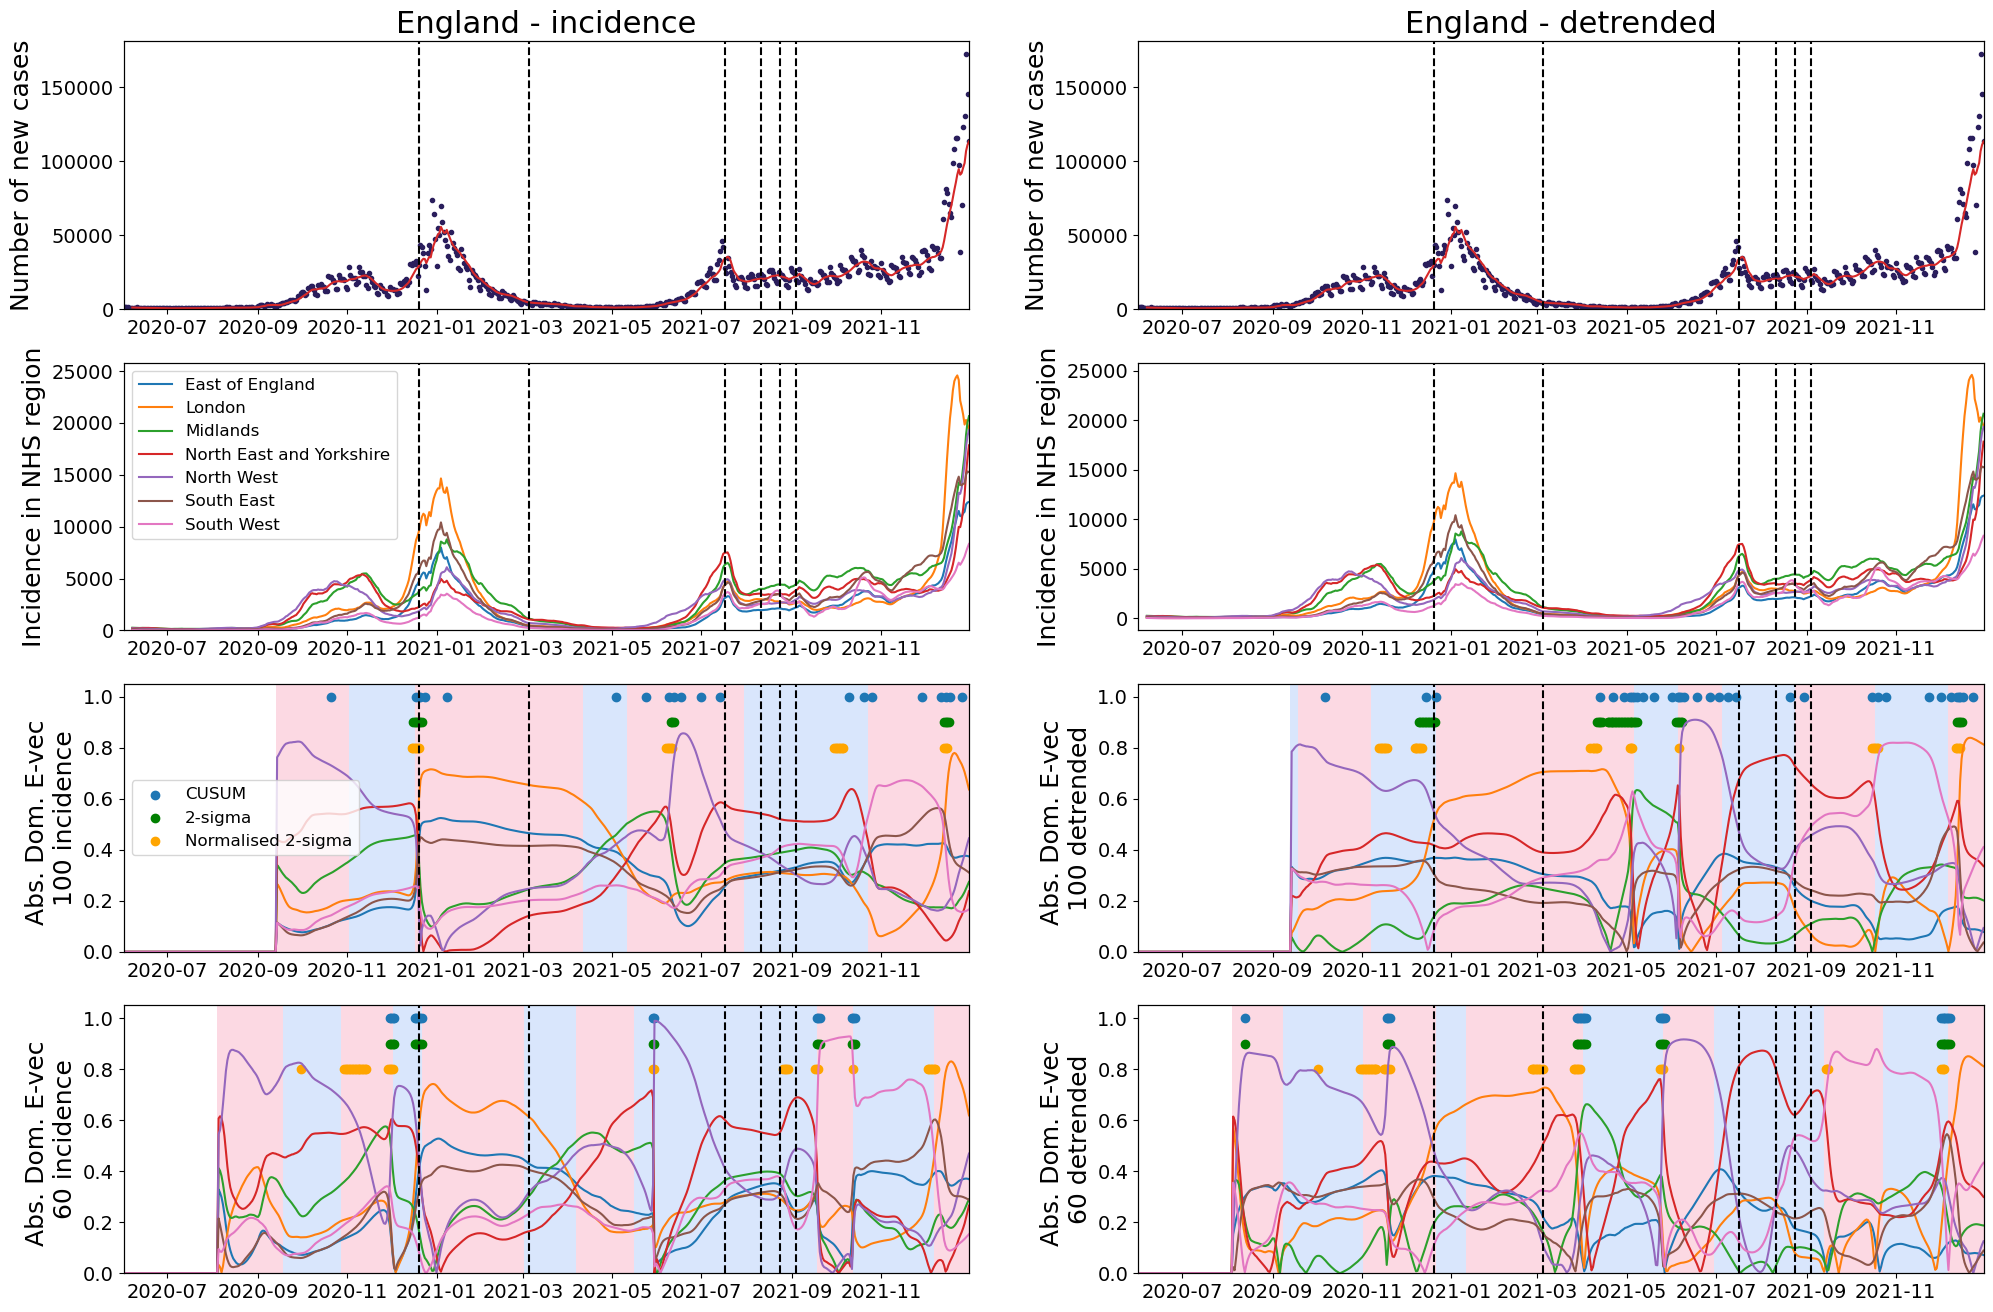

In [41]:
labs = ['East of England','London',"Midlands","North East and Yorkshire","North West","South East","South West"]
counts_nhs = deepcopy(cases_total)
counts_nhs = counts_nhs.reset_index()
cols = colormaps.get_cmap('tab10')(np.arange(10))
fig, axs = plt.subplots(nrows=4,ncols=2,figsize=(24,16))
axs[0,0].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,0].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,0].set_title('England - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[0,0].set_ylim((0,None))

for i in range(len(labs)):
    t = cases_nhs.loc[cases_nhs['region'] == labs[i], 'rolling']
    axs[1,0].plot(counts_nhs['date'], t,label=labs[i])
axs[1,0].set_ylabel('Incidence in NHS region',fontsize=18)
axs[1,0].legend(fontsize=12,loc='upper left')
axs[1,0].set_ylim((0,None))

for i in range(len(cov_100_evec[0])):
    axs[2,0].plot(counts_nhs['date'],np.abs(cov_100_evec[:,i]))
for (start, end), col in zip(pairwise(counts_nhs['date'].iloc[np.concatenate(([105],bkps_100))-1]), color_cycle):
    axs[2,0].axvspan(start, end, facecolor=col, alpha=0.2)
axs[2,0].scatter(counts_nhs['date'][ang_100_flags],np.ones(len(np.arange(len(cov_100_evec))[ang_100_flags])), label = 'CUSUM')
axs[2,0].scatter(counts_nhs['date'][ang_sig_100_flags], np.ones(len(ang_sig_100_flags))*0.9, color='g', label = '2-sigma')
axs[2,0].scatter(counts_nhs['date'][ang_normsig_100_flags], np.ones(len(ang_normsig_100_flags))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[2,0].set_ylabel('Abs. Dom. E-vec \n100 incidence',fontsize=18)
axs[2,0].legend(loc='center left',fontsize=12)
axs[2,0].set_ylim((0,None))

for i in range(len(cov_60_evec[0])):
    axs[3,0].plot(counts_nhs['date'],np.abs(cov_60_evec[:,i]))
for (start, end), col in zip(pairwise(counts_nhs['date'].iloc[np.concatenate(([65],bkps_60))-1]), color_cycle):
    axs[3,0].axvspan(start, end, facecolor=col, alpha=0.2)
axs[3,0].scatter(counts_nhs['date'][ang_60_flags],np.ones(len(np.arange(len(cov_60_evec))[ang_60_flags])), label = 'CUSUM')
axs[3,0].scatter(counts_nhs['date'][ang_sig_60_flags], np.ones(len(ang_sig_60_flags))*0.9, color='g', label = '2-sigma')
axs[3,0].scatter(counts_nhs['date'][ang_normsig_60_flags], np.ones(len(ang_normsig_60_flags))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[3,0].set_ylabel('Abs. Dom. E-vec \n60 incidence',fontsize=18)
axs[3,0].set_ylim((0,None))

axs[0,1].plot(counts_nhs['date'],counts_nhs['value'],'.',color='#2A1E5C')
axs[0,1].plot(counts_nhs['date'],counts_nhs['rolling'],color='#D62828')
axs[0,1].set_title('England - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[0,1].set_ylim((0,None))

for i in range(len(labs)):
    t = cases_nhs.loc[cases_nhs['region'] == labs[i], 'rolling']
    axs[1,1].plot(counts_nhs['date'],t,label=labs[i])
axs[1,1].set_ylabel('Incidence in NHS region',fontsize=18)

for i in range(len(cov_100_evec_det[0])):
    axs[2,1].plot(counts_nhs['date'],np.abs(cov_100_evec_det[:,i]))
for (start, end), col in zip(pairwise(counts_nhs['date'].iloc[np.concatenate(([105],bkps_100_det))-1]), color_cycle):
    axs[2,1].axvspan(start, end, facecolor=col, alpha=0.2)
axs[2,1].scatter(counts_nhs['date'][ang_100_flags_det],np.ones(len(np.arange(len(cov_100_evec_det))[ang_100_flags_det])), label = 'CUSUM')
axs[2,1].scatter(counts_nhs['date'][ang_sig_100_flags_det], np.ones(len(ang_sig_100_flags_det))*0.9, color='g', label = '2-sigma')
axs[2,1].scatter(counts_nhs['date'][ang_normsig_100_flags_det], np.ones(len(ang_normsig_100_flags_det))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[2,1].set_ylabel('Abs. Dom. E-vec \n100 detrended',fontsize=18)
axs[2,1].set_ylim((0,None))

for i in range(len(cov_60_evec_det[0])):
    axs[3,1].plot(counts_nhs['date'],np.abs(cov_60_evec_det[:,i]))
for (start, end), col in zip(pairwise(counts_nhs['date'].iloc[np.concatenate(([65],bkps_60_det))-1]), color_cycle):
    axs[3,1].axvspan(start, end, facecolor=col, alpha=0.2)
axs[3,1].scatter(counts_nhs['date'][ang_60_flags_det],np.ones(len(np.arange(len(cov_60_evec_det))[ang_60_flags_det])), label = 'CUSUM')
axs[3,1].scatter(counts_nhs['date'][ang_sig_60_flags_det], np.ones(len(ang_sig_60_flags_det))*0.9, color='g', label = '2-sigma')
axs[3,1].scatter(counts_nhs['date'][ang_normsig_60_flags_det], np.ones(len(ang_normsig_60_flags_det))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[3,1].set_ylabel('Abs. Dom. E-vec \n60 detrended',fontsize=18)
axs[3,1].set_ylim((0,None))

for i in range(4):
    for j in range(2):
        axs[i,j].set_xlim([counts_nhs['date'].to_numpy()[0],counts_nhs['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=ltla_transitions['Maidstone'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
        axs[i,j].tick_params(axis='both',labelsize=14)
plt.savefig("Figures/NHSevectors.pdf",dpi=2400,bbox_inches='tight')
plt.show()

## NHS age-structured

In [42]:
wide_data_total = pd.read_csv('regional_wide_total_10year_full.csv',header=[0,1], index_col=0)
wide_data_incidence = pd.read_csv('regional_wide_incidence_10year_full.csv',header=[0,1], index_col=0)
cases_plot = pd.read_csv('cases_region.csv')
cases_plot['date'] = pd.to_datetime(cases_plot['date'])
cases_plot.set_index('date',inplace=True)
counts = cases_plot[cases_plot['region']=='South East']

In [43]:
import pickle        
with open('nhs_transitions.pkl', 'rb') as f:
    nhs_transitions = pickle.load(f)

In [44]:
rolling = wide_data_incidence['South East'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total, cov_100_var, cov_100_evec, cov_100_evec2, V_store_100, Arot_norm_100 = eigen_decomp(cov)

rolling = wide_data_incidence['South East'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total, cov_60_var, cov_60_evec, cov_60_evec2, V_store_60, Arot_norm_60 = eigen_decomp(cov)

rolling = wide_data_total['South East'].rolling(window=100,center=False)
cov=rolling.cov()
cov_100_total_det, cov_100_var_det, cov_100_evec_det, cov_100_evec_det2, V_store_100_det, Arot_norm_100_det = eigen_decomp(cov)

rolling = wide_data_total['South East'].rolling(window=60,center=False)
cov=rolling.cov()
cov_60_total_det, cov_60_var_det, cov_60_evec_det, cov_60_evec_det2, V_store_60_det, Arot_norm_60_det = eigen_decomp(cov)

ang_100_flags, ang_sig_100_flags, ang_normsig_100_flags, bkps_100, ang_60_flags, ang_sig_60_flags, ang_normsig_60_flags, bkps_60 = get_signals_and_bkps(cov_100_evec, cov_60_evec,threshold = (0.2,0.4), std = (0.005,0.01), min_size = (20,20), pen = (20,20))
ang_100_flags_det, ang_sig_100_flags_det, ang_normsig_100_flags_det, bkps_100_det, ang_60_flags_det, ang_sig_60_flags_det, ang_normsig_60_flags_det, bkps_60_det = get_signals_and_bkps(cov_100_evec_det, cov_60_evec_det,threshold = (0.2,0.4), std = (0.005,0.01), min_size = (20,20), pen = (30,30))

/tmp/ipykernel_17290/993437236.py:33: RuntimeWarning: Mean of empty slice
  mean_val[j] = np.nanmean(normalise_stats[1:j+1])
/home/jlooker/anaconda3/envs/mathsysbase/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/tmp/ipykernel_17290/993437236.py:17: RuntimeWarning: Mean of empty slice
  mean_val[j] = np.nanmean(normalise_stats[1:j+1])


/tmp/ipykernel_17290/1701757526.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['cases'].rolling(7).mean()


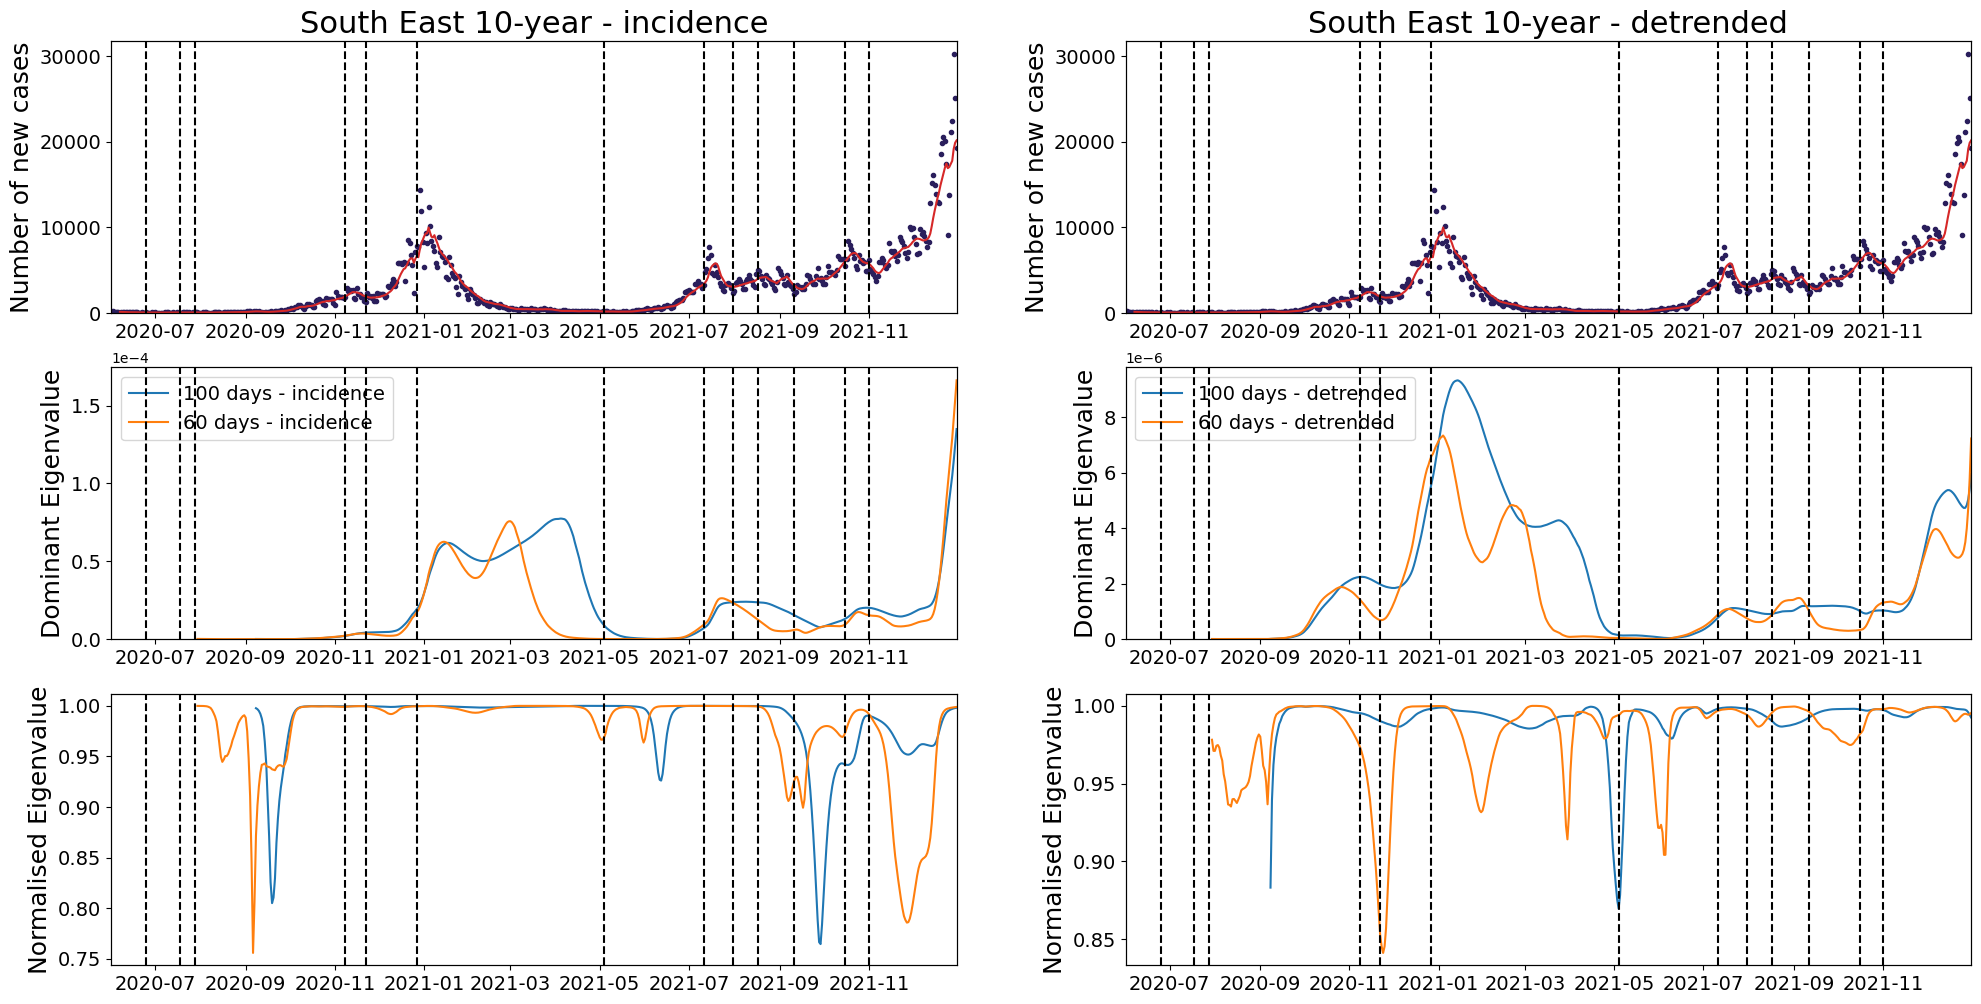

In [46]:
counts = cases_plot[cases_plot['region']=='South East']
fig, axs = plt.subplots(nrows=3,ncols=2,figsize=(24,12))
counts['rolling'] = counts['cases'].rolling(7).mean()
counts = counts.reset_index()
axs[0,0].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
# axs[0,0].set_ylim((0,14000))
axs[0,0].set_title('South East 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[1,0].plot(counts['date'],cov_100_total,label='100 days - incidence')
axs[2,0].plot(counts['date'],cov_100_var,label='100 days - incidence')
axs[1,0].plot(counts['date'],cov_60_total,label='60 days - incidence')
axs[2,0].plot(counts['date'],cov_60_var,label='60 days - incidence')
axs[1,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,0].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,0].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,0].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,0].legend(fontsize=14,loc='upper left')
axs[1,0].ticklabel_format(axis='y', style='scientific', scilimits=(0,0))
axs[1,0].set_ylim((0,None))
axs[0,0].set_ylim((0,None))

axs[0,1].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,1].set_title('South East 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[1,1].plot(counts['date'],cov_100_total_det,label='100 days - detrended')
axs[2,1].plot(counts['date'],cov_100_var_det,label='100 days - detrended')
axs[1,1].plot(counts['date'],cov_60_total_det,label='60 days - detrended')
axs[2,1].plot(counts['date'],cov_60_var_det,label='60 days - detrended')
axs[1,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[2,1].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
axs[1,1].set_ylabel('Dominant Eigenvalue',fontsize=18)
axs[2,1].set_ylabel('Normalised Eigenvalue', fontsize=18)
axs[1,1].legend(fontsize=14,loc='upper left')
axs[1,1].set_ylim((0,None))
axs[0,1].set_ylim((0,None))

for i in range(3):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=nhs_transitions['South East'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
        axs[i,j].tick_params(axis='both',labelsize=14)
plt.savefig("Figures/10yearevaluesregion.pdf",dpi=2400,bbox_inches='tight')
plt.show()

/tmp/ipykernel_17290/1835372078.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  counts['rolling'] = counts['cases'].rolling(7).mean()


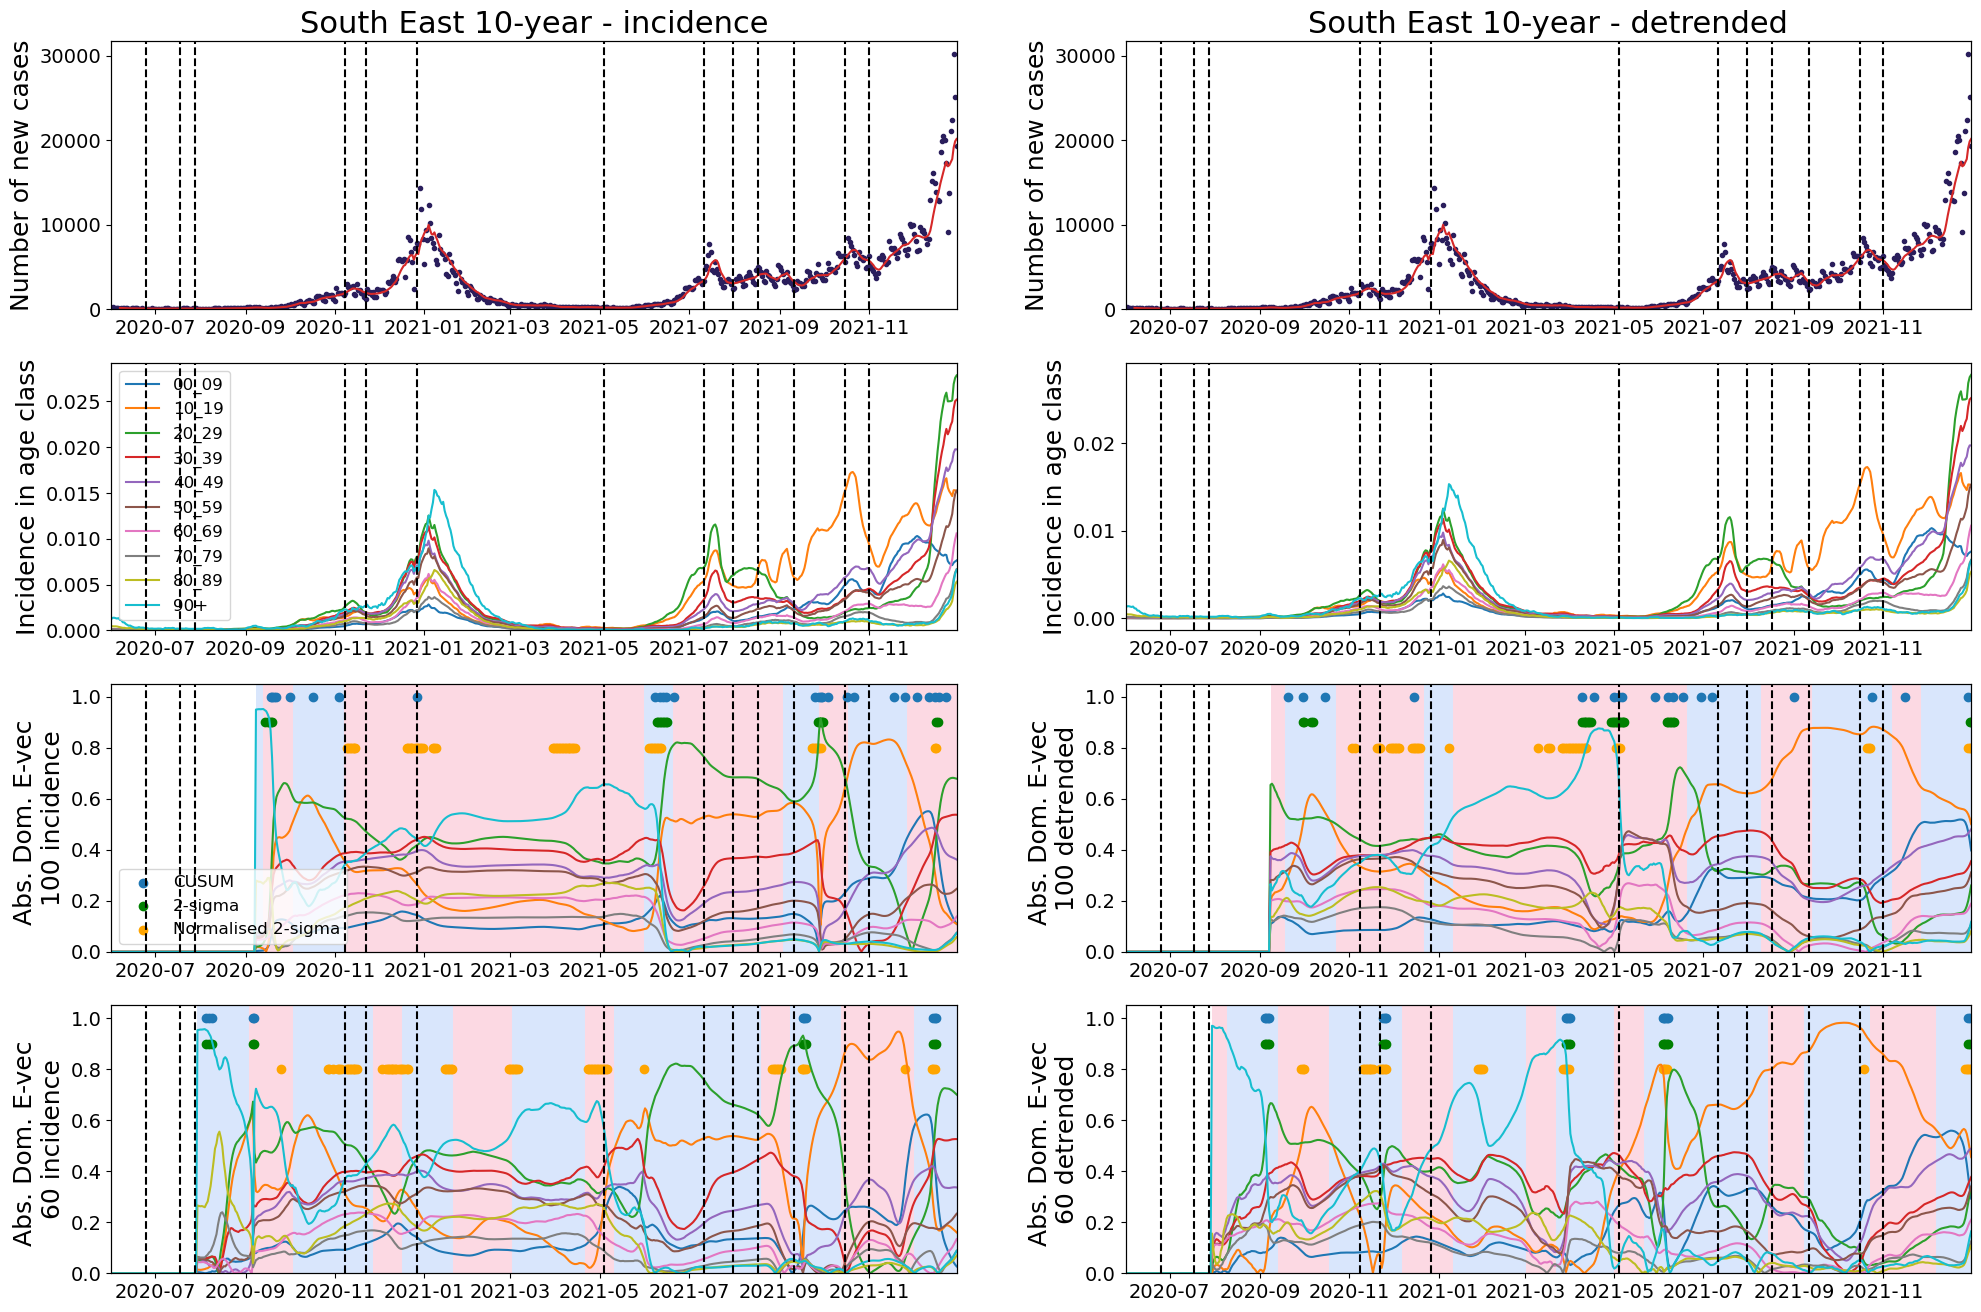

In [47]:
labs = ['00_09', '10_19', '20_29', '30_39', '40_49', '50_59', '60_69', '70_79','80_89', '90+']
counts = cases_plot[cases_plot['region']=='South East']
cols = colormaps.get_cmap('tab10')(np.arange(10))
fig, axs = plt.subplots(nrows=4,ncols=2,figsize=(24,16))
counts['rolling'] = counts['cases'].rolling(7).mean()
counts = counts.reset_index()

axs[0,0].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,0].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,0].set_title('South East 10-year - incidence',fontsize=22)
axs[0,0].set_ylabel('Number of new cases',fontsize=18)
axs[0,0].set_ylim((0,None))

for i in range(len(labs)):
    t = wide_data_incidence['South East'][labs[i]]
    axs[1,0].plot(counts['date'],t,label=labs[i])
axs[1,0].set_ylabel('Incidence in age class',fontsize=18)
axs[1,0].legend(fontsize=12,loc='upper left')
axs[1,0].set_ylim((0,None))

for i in range(len(cov_100_evec[0])):
    axs[2,0].plot(counts['date'],np.abs(cov_100_evec[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([100],bkps_100))-1]), color_cycle):
    axs[2,0].axvspan(start, end, facecolor=col, alpha=0.2)
axs[2,0].scatter(counts['date'][ang_100_flags],np.ones(len(np.arange(len(cov_100_evec))[ang_100_flags])), label = 'CUSUM')
axs[2,0].scatter(counts['date'][ang_sig_100_flags], np.ones(len(ang_sig_100_flags))*0.9, color='g', label = '2-sigma')
axs[2,0].scatter(counts['date'][ang_normsig_100_flags], np.ones(len(ang_normsig_100_flags))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[2,0].set_ylabel('Abs. Dom. E-vec \n100 incidence',fontsize=18)
axs[2,0].legend(loc='lower left',fontsize=12)
axs[2,0].set_ylim((0,None))

for i in range(len(cov_60_evec[0])):
    axs[3,0].plot(counts['date'],np.abs(cov_60_evec[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([60],bkps_60))-1]), color_cycle):
    axs[3,0].axvspan(start, end, facecolor=col, alpha=0.2)
axs[3,0].scatter(counts['date'][ang_60_flags],np.ones(len(np.arange(len(cov_60_evec))[ang_60_flags])), label = 'CUSUM')
axs[3,0].scatter(counts['date'][ang_sig_60_flags], np.ones(len(ang_sig_60_flags))*0.9, color='g', label = '2-sigma')
axs[3,0].scatter(counts['date'][ang_normsig_60_flags], np.ones(len(ang_normsig_60_flags))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[3,0].set_ylabel('Abs. Dom. E-vec \n60 incidence',fontsize=18)
axs[3,0].set_ylim((0,None))

axs[0,1].plot(counts['date'],counts['cases'],'.',color='#2A1E5C')
axs[0,1].plot(counts['date'],counts['rolling'],color='#D62828')
axs[0,1].set_title('South East 10-year - detrended',fontsize=22)
axs[0,1].set_ylabel('Number of new cases',fontsize=18)
axs[0,1].set_ylim((0,None))

for i in range(len(labs)):
    t = wide_data_incidence['South East'][labs[i]]
    axs[1,1].plot(counts['date'],t,label=labs[i])
axs[1,1].set_ylabel('Incidence in age class',fontsize=18)

for i in range(len(cov_100_evec_det[0])):
    axs[2,1].plot(counts['date'],np.abs(cov_100_evec_det[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([100],bkps_100_det))-1]), color_cycle):
    axs[2,1].axvspan(start, end, facecolor=col, alpha=0.2)
axs[2,1].scatter(counts['date'][ang_100_flags_det],np.ones(len(np.arange(len(cov_100_evec_det))[ang_100_flags_det])), label = 'CUSUM')
axs[2,1].scatter(counts['date'][ang_sig_100_flags_det], np.ones(len(ang_sig_100_flags_det))*0.9, color='g', label = '2-sigma')
axs[2,1].scatter(counts['date'][ang_normsig_100_flags_det], np.ones(len(ang_normsig_100_flags_det))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[2,1].set_ylabel('Abs. Dom. E-vec \n100 detrended',fontsize=18)
axs[2,1].set_ylim((0,None))

for i in range(len(cov_60_evec_det[0])):
    axs[3,1].plot(counts['date'],np.abs(cov_60_evec_det[:,i]))
for (start, end), col in zip(pairwise(counts['date'].iloc[np.concatenate(([60],bkps_60_det))-1]), color_cycle):
    axs[3,1].axvspan(start, end, facecolor=col, alpha=0.2)
axs[3,1].scatter(counts['date'][ang_60_flags_det],np.ones(len(np.arange(len(cov_60_evec_det))[ang_60_flags_det])), label = 'CUSUM')
axs[3,1].scatter(counts['date'][ang_sig_60_flags_det], np.ones(len(ang_sig_60_flags_det))*0.9, color='g', label = '2-sigma')
axs[3,1].scatter(counts['date'][ang_normsig_60_flags_det], np.ones(len(ang_normsig_60_flags_det))*0.8, color='orange', label = 'Normalised 2-sigma')
axs[3,1].set_ylabel('Abs. Dom. E-vec \n60 detrended',fontsize=18)
axs[3,1].set_ylim((0,None))

for i in range(4):
    for j in range(2):
        axs[i,j].set_xlim([counts['date'].to_numpy()[0],counts['date'].to_numpy()[-1]])
        ax = axs[i,j].twinx()
        ax.vlines(x=nhs_transitions['South East'][:-1],ymin=-1,ymax=1,color='k',label='Critical Transition',linestyle='--')
        ax.set_ylim((-1,1))
        ax.get_yaxis().set_ticks([])
        axs[i,j].tick_params(axis='both',labelsize=14)
plt.savefig("Figures/10yearevectorsregion.pdf",dpi=2400,bbox_inches='tight')
plt.show()